### Dans ce notebook, on va utiliser le pretrained model efficientNetB0 pour la detection du deepfake videos 
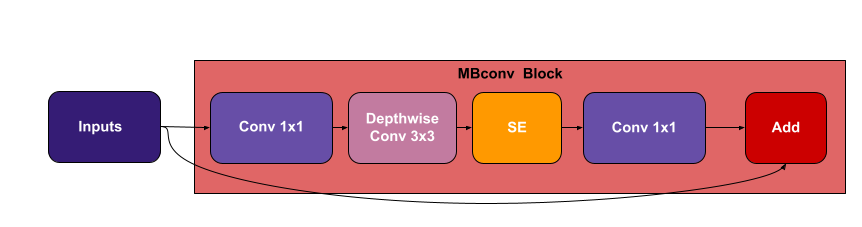

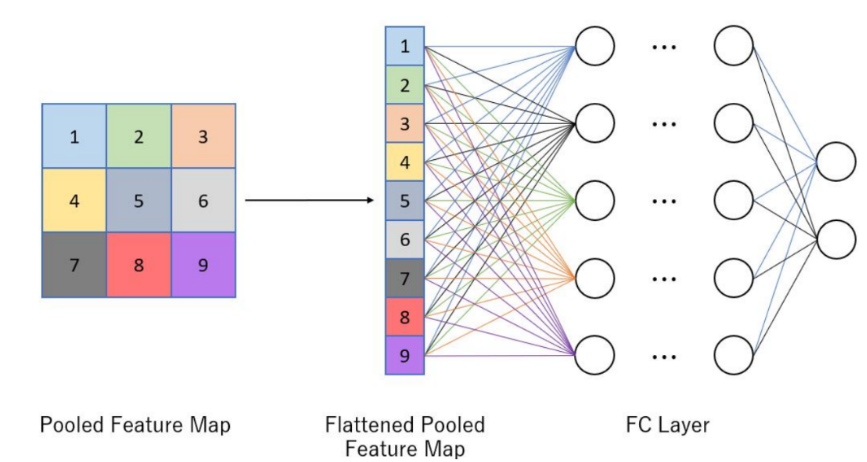
### EfficientNetB0 est une architecture CNN moderne conçue par Google pour maximiser la performance tout en minimisant le nombre de paramètre
🟢 Étape 1 : détecter des choses simples
lignes
contours
couleurs
🔵 Étape 2 : détecter des motifs
textures de peau
yeux, bouche
🔴 Étape 3 : comprendre l’image
visage réel / anomalies (deepfake) 

# Étape 1 : Installation des packages

In [1]:
# On installe UNIQUEMENT grad-cam, sans le laisser toucher à l'environnement Kaggle !
# On installe grad-cam ET ttach, toujours sans toucher au reste de Kaggle !
!pip install grad-cam ttach --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=eaed8f07234205b75bd9c787c520ffa85a8699a87fd0a4b9f51985ed7d8ab679
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
# !pip install "numpy==1.26.4" Pillow==9.5.0 mediapipe facenet-pytorch grad-cam opencv-python-headless matplotlib seaborn pandas scikit-learn

In [3]:
# !pip install "numpy<2.0.0" Pillow==9.5.0
# !pip install mediapipe

In [4]:
# !pip install facenet-pytorch
# !pip install grad-cam
# !pip install torch torchvision
# !pip install opencv-python-headless
# !pip install matplotlib seaborn pandas scikit-learn

# Étape 2 : Imports et configuration GPU/CPU

In [5]:
import os
import cv2
import json
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from tqdm.notebook import tqdm
from PIL import Image

# Le device pour l'entraînement
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Tout fonctionne ! Device utilisé : {device}")

Tout fonctionne ! Device utilisé : cuda


In [6]:
# Configuration des devices (Utilisation des 2 GPU T4 si disponibles)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé : {device}")
if torch.cuda.device_count() > 1:
    print(f"{torch.cuda.device_count()} GPUs disponibles !")

Device utilisé : cuda
2 GPUs disponibles !


# Étape 3 : Data Exploration

In [7]:
# Chemins
DATA_DIR = '/kaggle/input/competitions/deepfake-detection-challenge'
TRAIN_VIDEOS_DIR = os.path.join(DATA_DIR, 'train_sample_videos')
META_PATH = os.path.join(TRAIN_VIDEOS_DIR, 'metadata.json')

In [8]:
# Chargement des métadonnées
with open(META_PATH, 'r') as f:
    metadata = json.load(f)

df = pd.DataFrame.from_dict(metadata, orient='index').reset_index()
df = df.rename(columns={'index': 'video_name'})

/tmp/ipykernel_23/1902948474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


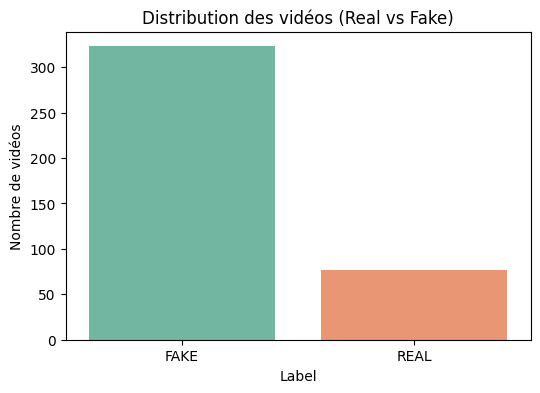

label
FAKE    323
REAL     77
Name: count, dtype: int64


In [9]:
# Plot de la distribution des classes
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Distribution des vidéos (Real vs Fake)')
plt.xlabel('Label')
plt.ylabel('Nombre de vidéos')
plt.show()

print(df['label'].value_counts())

In [10]:
# Fonction pour afficher une frame d'une vidéo
def show_video_sample(video_path, title):
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame)
        plt.title(title)
        plt.axis('off')
    cap.release()

In [11]:
# Quelques exemples de vidéos/frames
def display_sample_frames(video_path, num_frames=5):
    cap = cv2.VideoCapture(video_path)
    frames = []
    for i in range(num_frames):
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
    cap.release()
    
    fig, axs = plt.subplots(1, len(frames), figsize=(15, 5))
    for ax, frm in zip(axs, frames):
        ax.imshow(frm)
        ax.axis('off')
    plt.show()

# Étape 4 : Face Extraction 
On extrait le visage principal avec MTCNN sur GPU T4.
Cette étape est cruciale pour la performance. Nous extrayons quelques frames de chaque vidéo, recadrons les visages et les sauvegardons dans /kaggle/working/

In [12]:
import os
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
import urllib.request

# ==========================================
# TÉLÉCHARGEMENT DU MODÈLE OPENCV DEEP LEARNING
# ==========================================
prototxt_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

prototxt_path = "/kaggle/working/deploy.prototxt"
model_path = "/kaggle/working/res10_300x300_ssd_iter_140000.caffemodel"

# Téléchargement unique si les fichiers n'existent pas encore
if not os.path.exists(prototxt_path):
    urllib.request.urlretrieve(prototxt_url, prototxt_path)
if not os.path.exists(model_path):
    urllib.request.urlretrieve(model_url, model_path)

# Initialisation du réseau de neurones OpenCV
net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)
# ==========================================

FACES_DIR = '/kaggle/working/faces'
os.makedirs(FACES_DIR, exist_ok=True)

processed_data = []
FRAMES_PER_VIDEO = 5 # Nombre de frames à extraire

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extraction (OpenCV DNN)"):
    video_name = row['video_name']
    label = 1 if row['label'] == 'FAKE' else 0
    video_path = os.path.join(TRAIN_VIDEOS_DIR, video_name)
    
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if frame_count == 0: continue
    
    frame_idxs = np.linspace(0, frame_count - 1, FRAMES_PER_VIDEO, dtype=int)
    
    for i, frame_idx in enumerate(frame_idxs):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        
        if ret:
            h, w = frame.shape[:2]
            # Préparation de l'image pour le modèle
            blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
            net.setInput(blob)
            detections = net.forward()
            
            # On cherche le visage le plus confiant
            max_conf = 0
            best_box = None
            
            for j in range(0, detections.shape[2]):
                confidence = detections[0, 0, j, 2]
                if confidence > 0.5 and confidence > max_conf: # Seuil de 50%
                    max_conf = confidence
                    box = detections[0, 0, j, 3:7] * np.array([w, h, w, h])
                    best_box = box.astype("int")
            
            # Si on a trouvé un visage
            if best_box is not None:
                (startX, startY, endX, endY) = best_box
                
                # Sécuriser les bords de l'image
                startX, startY = max(0, startX), max(0, startY)
                endX, endY = min(w, endX), min(h, endY)
                
                face_img = frame[startY:endY, startX:endX]
                
                if face_img.size != 0:
                    face_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
                    img = Image.fromarray(face_rgb)
                    save_path = os.path.join(FACES_DIR, f"{video_name.split('.')[0]}_frame{i}.jpg")
                    img.save(save_path)
                    processed_data.append({'image_path': save_path, 'label': label})
                    
    cap.release()

df_faces = pd.DataFrame(processed_data)
print(f"Total de visages extraits : {len(df_faces)}")

Extraction (OpenCV DNN):   0%|          | 0/400 [00:00<?, ?it/s]

Total de visages extraits : 1500


# Étape 4 : DataLoader et Préparation et gestion du déséquilibre
Nous appliquons les poids pour pallier le déséquilibre des classes et préparons le DataLoader (avec num_workers pour optimiser le CPU).

In [13]:
class DeepfakeDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

In [14]:
# Transforms avec Data Augmentation pour l'entraînement
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [15]:
# Transforms simples pour la validation et le test
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [16]:
from sklearn.model_selection import train_test_split

# Split stratifié (80/20)
train_df, val_df = train_test_split(df_faces, test_size=0.2, random_state=42, stratify=df_faces['label'])

In [17]:
# Création des Datasets
train_dataset = DeepfakeDataset(train_df, transform=train_transform)
val_dataset = DeepfakeDataset(val_df, transform=val_transform)

In [18]:
# 5. Création des DataLoaders (num_workers=0 force l'exécution sur le processus principal)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

In [19]:
# Calcul des poids pour le déséquilibre (basé uniquement sur le train_df)
num_real = len(train_df[train_df['label'] == 0])
num_fake = len(train_df[train_df['label'] == 1])
total = len(train_df)

weight_real = total / (2 * num_real)
weight_fake = total / (2 * num_fake)
class_weights = torch.FloatTensor([weight_real, weight_fake]).to(device)

print(f"Poids appliqués (Train) : Real = {weight_real:.2f}, Fake = {weight_fake:.2f}")

Poids appliqués (Train) : Real = 2.33, Fake = 0.64


# Cellule 5 : Entraînement du modèle (Fine-Tuning) et Courbes

In [20]:
# Chargement d'EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


In [21]:
# Remplacement de la dernière couche pour 2 classes
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, 2)

In [22]:
# Parallélisation si plusieurs GPUs sont disponibles
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

In [23]:
!pip install "numpy==1.26.4" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.

In [24]:
# Fonction de perte pondérée
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001) # Learning rate plus petit pour le Fine-Tuning

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
EPOCHS = 10
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for epoch in range(EPOCHS):
    # Phase d'entraînement
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_loss = running_loss / total
    train_acc = correct / total
    
    # Phase de validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    val_loss = val_loss / total
    val_acc = correct / total
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    # Sauvegarde des Checkpoints
    torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/effnet_b0_epoch_{epoch+1}.pth")

Epoch 1/10 [Train]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.6339 Acc: 0.6075 | Val Loss: 0.5657 Acc: 0.6667


Epoch 2/10 [Train]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.4734 Acc: 0.7550 | Val Loss: 0.5134 Acc: 0.6333


Epoch 3/10 [Train]:   0%|          | 0/38 [00:00<?, ?it/s]

...

Epoch 8 | Train Loss: 0.1710 Acc: 0.9283 | Val Loss: 0.2276 Acc: 0.9033


Epoch 9/10 [Train]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 9 | Train Loss: 0.1415 Acc: 0.9425 | Val Loss: 0.2001 Acc: 0.8967


Epoch 10/10 [Train]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 0.1138 Acc: 0.9575 | Val Loss: 0.2184 Acc: 0.8867


In [25]:
# Sauvegarde finale
torch.save(model.state_dict(), '/kaggle/working/effnet_b0_final.pth')
print("Entraînement terminé et modèle sauvegardé !")

Entraînement terminé et modèle sauvegardé !


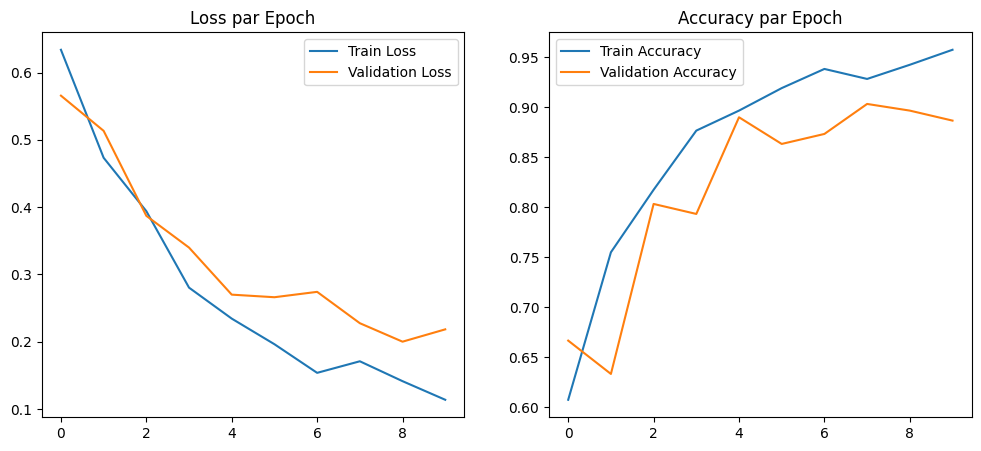

In [26]:
# Affichage des courbes
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss par Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy par Epoch')
plt.legend()
plt.show()

# Cellule 6 : Évaluation sur une vidéo test et XAI (Grad-CAM)

In [27]:
# Gestion de la couche cible pour DataParallel
target_model = model.module if isinstance(model, nn.DataParallel) else model
target_layers = [target_model.features[-1]] 

cam = GradCAM(model=target_model, target_layers=target_layers)

In [28]:
def evaluate_video_with_xai(video_path):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, 10) # 10ème frame
    ret, frame = cap.read()
    cap.release()
    
    if not ret:
        print("Erreur de lecture de la vidéo")
        return
        
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    h, w = frame.shape[:2]
    
    # Détection OpenCV DNN
    prototxt_path = "/kaggle/working/deploy.prototxt"
    model_path = "/kaggle/working/res10_300x300_ssd_iter_140000.caffemodel"
    net = cv2.dnn.readNetFromCaffe(prototxt_path, model_path)
    
    blob = cv2.dnn.blobFromImage(cv2.resize(frame, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    net.setInput(blob)
    detections = net.forward()
    
    max_conf = 0
    best_box = None
    for j in range(0, detections.shape[2]):
        confidence = detections[0, 0, j, 2]
        if confidence > 0.5 and confidence > max_conf:
            max_conf = confidence
            best_box = (detections[0, 0, j, 3:7] * np.array([w, h, w, h])).astype("int")
            
    if best_box is None:
        print("Aucun visage détecté.")
        return
        
    (startX, startY, endX, endY) = best_box
    startX, startY = max(0, startX), max(0, startY)
    endX, endY = min(w, endX), min(h, endY)
    
    face_img = frame_rgb[startY:endY, startX:endX]
    face_pil = Image.fromarray(face_img)
    
    # Inférence (avec val_transform pour éviter la data augmentation)
    input_tensor = val_transform(face_pil).unsqueeze(0).to(device)
    
    target_model.eval()
    with torch.no_grad():
        outputs = target_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        prob_fake = probabilities[1].item() * 100
        predicted_class = "FAKE" if probabilities[1] > probabilities[0] else "REAL"
    
    # Grad-CAM
    targets = [ClassifierOutputTarget(1)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
    face_resized = cv2.resize(face_img, (224, 224))
    face_normalized = np.float32(face_resized) / 255
    cam_image = show_cam_on_image(face_normalized, grayscale_cam, use_rgb=True)
    
    # Affichage
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(frame_rgb)
    plt.title("Frame Originale")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(face_pil)
    plt.title(f"Visage Extrait\nScore Fake: {prob_fake:.2f}%\nPrédiction: {predicted_class}")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(cam_image)
    plt.title("Explicabilité Grad-CAM")
    plt.axis('off')
    
    plt.show()

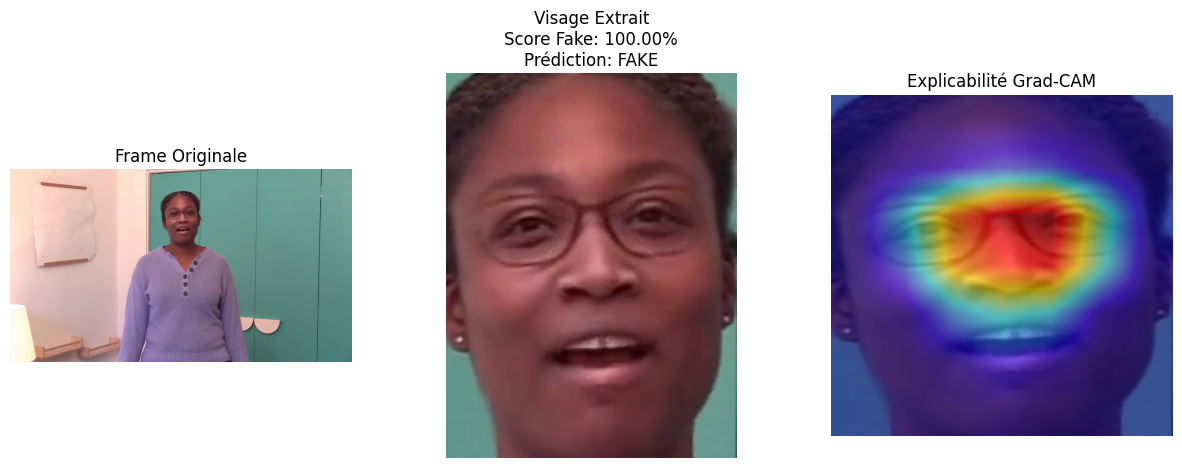

In [29]:
# Testons le modèle sur une vidéo
test_vid = os.path.join(TRAIN_VIDEOS_DIR, df['video_name'].iloc[15]) 
evaluate_video_with_xai(test_vid)

In [30]:
# def evaluate_video_with_xai(video_path):
#     cap = cv2.VideoCapture(video_path)
#     cap.set(cv2.CAP_PROP_POS_FRAMES, 10) # Prise d'une frame (ex: la 10ème)
#     ret, frame = cap.read()
#     cap.release()
    
#     if not ret:
#         print("Erreur de lecture de la vidéo")
#         return
        
#     frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
#     mtcnn_eval = MTCNN(keep_all=False, device=device)
#     boxes, probs = mtcnn_eval.detect(frame_rgb)
    
#     if boxes is None:
#         print("Aucun visage détecté.")
#         return
        
#     x1, y1, x2, y2 = [int(b) for b in boxes[0]]
#     face_img = frame_rgb[y1:y2, x1:x2]
#     face_pil = Image.fromarray(face_img)
    
#     # Application de la transformation DE VALIDATION (Sans Data Augmentation)
#     input_tensor = val_transform(face_pil).unsqueeze(0).to(device)
    
#     # Inférence
#     target_model.eval()
#     with torch.no_grad():
#         outputs = target_model(input_tensor)
#         probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
#         prob_fake = probabilities[1].item() * 100
#         predicted_class = "FAKE" if probabilities[1] > probabilities[0] else "REAL"
    
#     # Grad-CAM centré sur la classe "FAKE"
#     targets = [ClassifierOutputTarget(1)]
#     grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
    
#     face_resized = cv2.resize(face_img, (224, 224))
#     face_normalized = np.float32(face_resized) / 255
#     cam_image = show_cam_on_image(face_normalized, grayscale_cam, use_rgb=True)
    
#     # Affichage
#     plt.figure(figsize=(15, 5))
    
#     plt.subplot(1, 3, 1)
#     plt.imshow(frame_rgb)
#     plt.title("Frame Originale")
#     plt.axis('off')
    
#     plt.subplot(1, 3, 2)
#     plt.imshow(face_pil)
#     plt.title(f"Visage Extrait\nScore Fake: {prob_fake:.2f}%\nPrédiction: {predicted_class}")
#     plt.axis('off')
    
#     plt.subplot(1, 3, 3)
#     plt.imshow(cam_image)
#     plt.title("Explicabilité Grad-CAM")
#     plt.axis('off')
    
#     plt.show()